<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>

---

# Classical VRP — multi-vehicle routing

The Vehicle Routing Problem generalises TSP: a fleet of $K$ vehicles based
at a depot must collectively visit every customer, minimising total
distance. The plainest variant — uncapacitated, all $K$ vehicles must be
used, every customer visited exactly once by exactly one vehicle — is
called **m-VRP** (multi-vehicle TSP). VRP is NP-hard.

`VRPInstance` defaults to m-VRP: with only `n_customers` and `n_vehicles`
specified, every customer is assigned demand 1 and the per-vehicle capacity
is set to $\lceil n / K \rceil$. That default forces a balanced partition
across all $K$ vehicles. Pass `demands=` and `capacity=` explicitly for a
classical CVRP.

This notebook covers four solvers in `strasbourg_markets_demo.vrp`:

- **Brute force** (`m_vrp_brute_force`) — exhaustive over surjective
  assignments; the proven optimum for small instances ($n \le 10$).
- **Nearest-neighbour** — greedy round-robin, fast, usually poor.
- **Clarke–Wright savings** (1964) — classical merge-based heuristic.
- **OR-tools `RoutingModel`** — Google's industrial routing solver
  (`PATH_CHEAPEST_ARC` first solution + `GUIDED_LOCAL_SEARCH` metaheuristic).


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from strasbourg_markets_demo import strasbourg as s, theme
from strasbourg_markets_demo.vrp import (
    VRPInstance, m_vrp_brute_force, nearest_neighbour,
    clarke_wright_savings, or_tools_solve,
)

theme.apply()
RNG_SEED = 2024


## A small random m-VRP — 8 customers, 3 vehicles

No demands, no capacity supplied: the instance defaults to m-VRP with
balanced partitions ($\lceil 8/3 \rceil = 3$ customers per vehicle max).

customers : 8
vehicles  : 3
capacity  : 3.0    (auto, ceil(n/K))
demands   : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
is_mvrp   : True


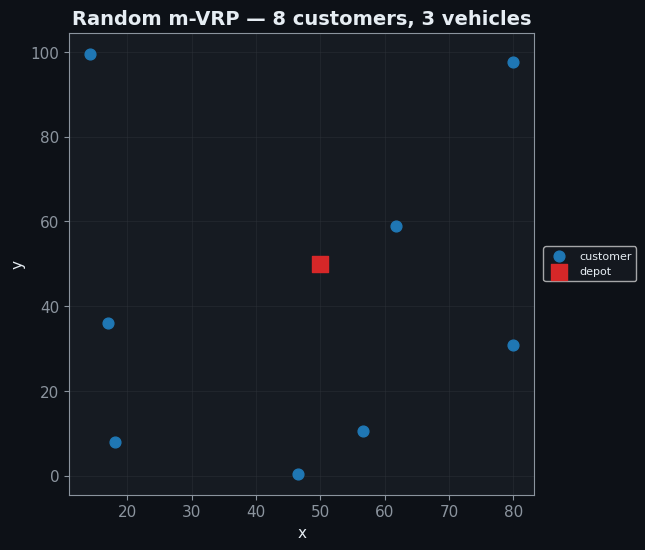

In [2]:
inst = VRPInstance.random(n_customers=8, n_vehicles=3, seed=RNG_SEED)
print(f"customers : {inst.n_customers}")
print(f"vehicles  : {inst.n_vehicles}")
print(f"capacity  : {inst.capacity}    (auto, ceil(n/K))")
print(f"demands   : {inst.demands.tolist()}")
print(f"is_mvrp   : {inst.is_mvrp}")

fig, ax = plt.subplots(figsize=(6, 6))
inst.plot(ax=ax)
ax.set_title("Random m-VRP — 8 customers, 3 vehicles")
plt.show()


## Brute force — the proven optimum

brute force      : total distance 431.6268    time 33.3 ms
  vehicle 0: [1, 6, 7]
  vehicle 1: [2, 8, 5]
  vehicle 2: [3, 4]


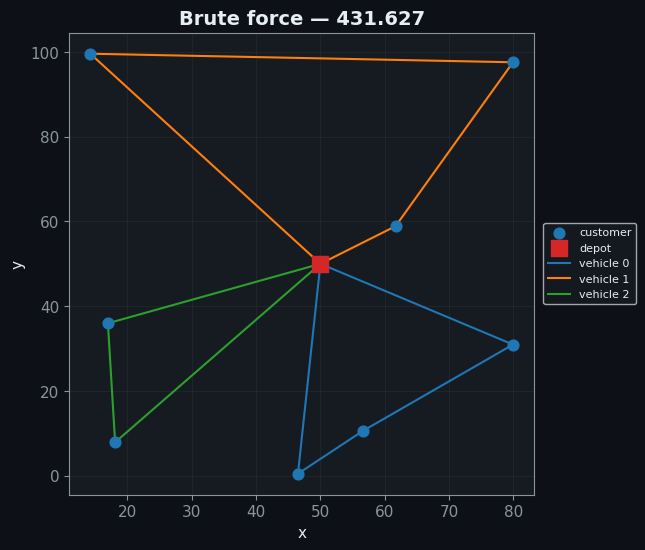

In [3]:
t0 = time.perf_counter()
routes_bf, total_bf = m_vrp_brute_force(inst)
t_bf = time.perf_counter() - t0
print(f"brute force      : total distance {total_bf:.4f}    time {t_bf*1e3:.1f} ms")
for k, r in enumerate(routes_bf):
    print(f"  vehicle {k}: {r}")

fig, ax = plt.subplots(figsize=(6, 6))
inst.plot(routes=routes_bf, ax=ax)
ax.set_title(f"Brute force — {total_bf:.3f}")
plt.show()


## Heuristics: nearest-neighbour, Clarke-Wright, OR-tools

In [4]:
t0 = time.perf_counter(); routes_nn = nearest_neighbour(inst);            t_nn = time.perf_counter() - t0
t0 = time.perf_counter(); routes_cw = clarke_wright_savings(inst);        t_cw = time.perf_counter() - t0
t0 = time.perf_counter(); routes_or, total_or = or_tools_solve(inst, time_limit_s=2); t_or = time.perf_counter() - t0
total_nn = inst.total_distance(routes_nn)
total_cw = inst.total_distance(routes_cw)

print(f"{'solver':22s}  {'total':>8s}  {'gap %':>6s}  {'time (ms)':>10s}")
print("-" * 54)
for name, total, t in [
    ("brute force",        total_bf, t_bf),
    ("nearest-neighbour",  total_nn, t_nn),
    ("clarke-wright",      total_cw, t_cw),
    ("or-tools",           total_or, t_or),
]:
    gap = (total / total_bf - 1) * 100
    print(f"{name:22s}  {total:8.4f}  {gap:6.2f}  {t*1e3:10.1f}")


solver                     total   gap %   time (ms)
------------------------------------------------------
brute force             431.6268    0.00        33.3
nearest-neighbour       445.2201    3.15         0.1
clarke-wright           441.5383    2.30         0.1
or-tools                431.6268    0.00      2046.8


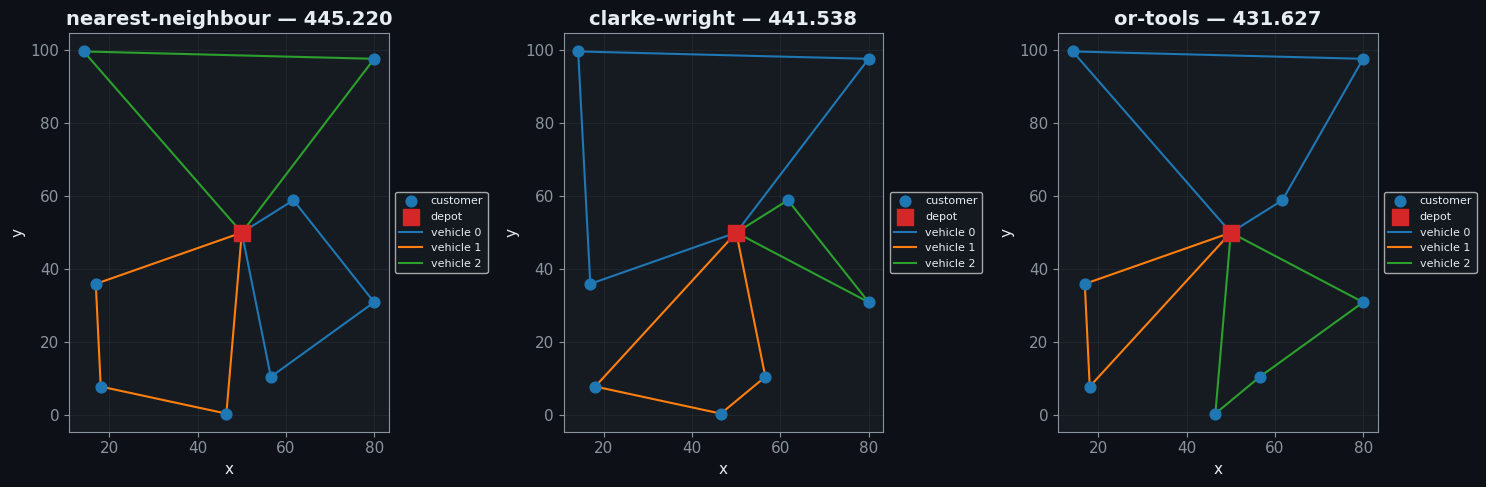

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, routes) in zip(axes, [
    ("nearest-neighbour", routes_nn),
    ("clarke-wright",     routes_cw),
    ("or-tools",          routes_or),
]):
    inst.plot(routes=routes, ax=ax)
    ax.set_title(f"{name} — {inst.total_distance(routes):.3f}")
plt.tight_layout(); plt.show()


## Larger random instance — 20 customers, 4 vehicles

Brute force is no longer tractable ($K^n = 4^{20} \approx 10^{12}$), so
we compare the three heuristics.

nearest-neighbour :   661.63    time     0.1 ms
clarke-wright     :   586.22    time     0.2 ms
or-tools          :   571.71    time  3002.7 ms


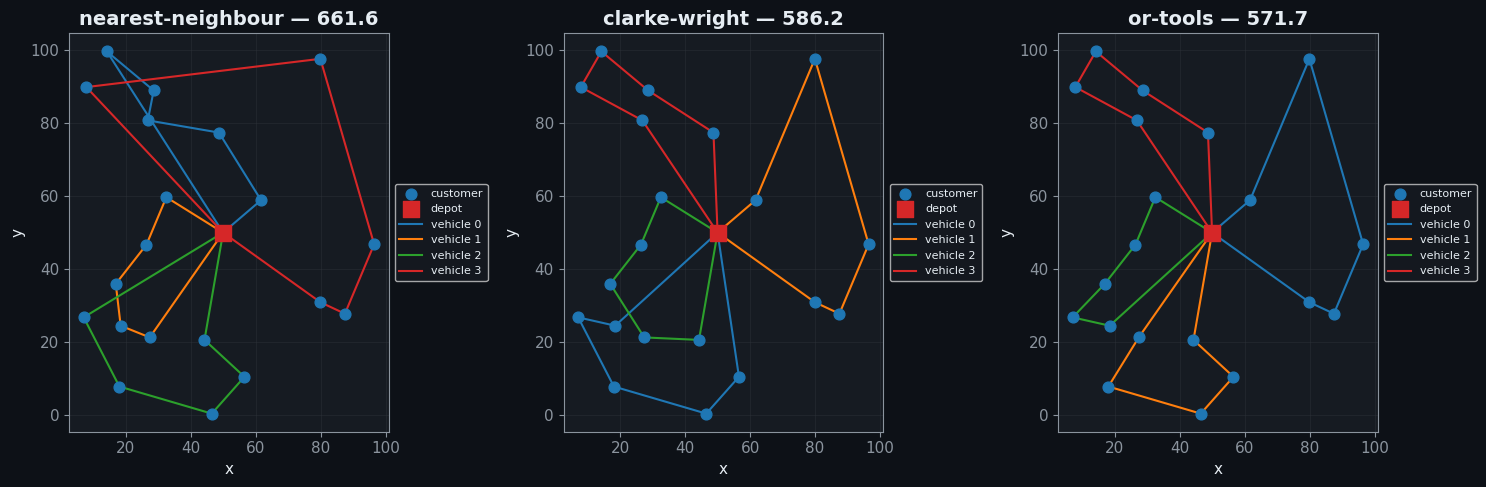

In [6]:
inst_big = VRPInstance.random(n_customers=20, n_vehicles=4, seed=RNG_SEED)

t0 = time.perf_counter(); r_nn = nearest_neighbour(inst_big);            t_nn = time.perf_counter() - t0
t0 = time.perf_counter(); r_cw = clarke_wright_savings(inst_big);        t_cw = time.perf_counter() - t0
t0 = time.perf_counter(); r_or, total_or = or_tools_solve(inst_big, time_limit_s=3); t_or = time.perf_counter() - t0

print(f"nearest-neighbour : {inst_big.total_distance(r_nn):8.2f}    time {t_nn*1e3:7.1f} ms")
print(f"clarke-wright     : {inst_big.total_distance(r_cw):8.2f}    time {t_cw*1e3:7.1f} ms")
print(f"or-tools          : {total_or:8.2f}    time {t_or*1e3:7.1f} ms")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, routes) in zip(axes, [
    ("nearest-neighbour", r_nn), ("clarke-wright", r_cw), ("or-tools", r_or)
]):
    inst_big.plot(routes=routes, ax=ax)
    ax.set_title(f"{name} — {inst_big.total_distance(routes):.1f}")
plt.tight_layout(); plt.show()


## Strasbourg bike couriers — m-VRP

> *From the Gare de Strasbourg, three bike couriers fan out across the
> Christmas markets to deliver crates of mulled-wine glasses. Each courier
> starts and ends at the station; collectively they must cover all five
> markets plus Petite France. Find the partition of stops to couriers and
> each courier's visit order that minimises total cycling distance.*

That's m-VRP: same depot, $K=3$ couriers, $n=6$ customers, no capacity in
the original sense (every market just needs *one* visit). The capacity
default $\lceil 6/3 \rceil = 2$ stops per courier balances the load.

We solve it three ways — brute force (proven optimum at this size),
Clarke–Wright, and OR-tools — then plot the routes colour-coded per
courier on the OSM basemap.

In [7]:
inst_str = VRPInstance.strasbourg_markets(n_vehicles=3)
print(f"customers : {inst_str.n_customers}    "
      f"vehicles : {inst_str.n_vehicles}    "
      f"capacity : {inst_str.capacity} stops/courier")

routes_bf, total_bf = m_vrp_brute_force(inst_str)
routes_cw          = clarke_wright_savings(inst_str)
routes_or, total_or = or_tools_solve(inst_str, time_limit_s=2)
total_cw = inst_str.total_distance(routes_cw)

print()
for label, routes, total in [
    ("brute force",   routes_bf, total_bf),
    ("clarke-wright", routes_cw, total_cw),
    ("or-tools",      routes_or, total_or),
]:
    print(f"--- {label}  ({total:.4f} km) ---")
    for k, route in enumerate(routes):
        nodes = " -> ".join(inst_str.names[i] if i else "Gare" for i in [0] + route + [0])
        print(f"  courier {k}: {nodes}")
    print()


customers : 5    vehicles : 3    capacity : 2.0 stops/courier

--- brute force  (6.1906 km) ---
  courier 0: Gare -> Place Broglie -> Place Kléber -> Gare
  courier 1: Gare -> Cathédrale Notre-Dame (marché) -> Place du Château -> Gare
  courier 2: Gare -> La Petite France -> Gare

--- clarke-wright  (6.1906 km) ---
  courier 0: Gare -> Place Broglie -> Place Kléber -> Gare
  courier 1: Gare -> Cathédrale Notre-Dame (marché) -> Place du Château -> Gare
  courier 2: Gare -> La Petite France -> Gare

--- or-tools  (6.1906 km) ---
  courier 0: Gare -> Cathédrale Notre-Dame (marché) -> Place du Château -> Gare
  courier 1: Gare -> La Petite France -> Gare
  courier 2: Gare -> Place Broglie -> Place Kléber -> Gare



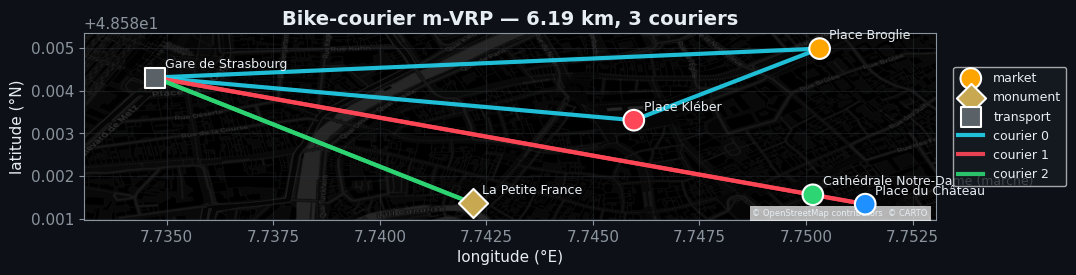

In [8]:
depot, customers = s.vrp_default()
all_places = (depot,) + tuple(customers)

palette_cycle = [theme.PALETTE["cyan"], theme.PALETTE["red"],
                 theme.PALETTE["green"], theme.PALETTE["yellow"]]

fig, ax = plt.subplots(figsize=(11, 9))
s.plot(places=all_places, ax=ax, basemap=True, label="name",
       title=f"Bike-courier m-VRP — {total_bf:.2f} km, {len(routes_bf)} couriers")

for k, route in enumerate(routes_bf):
    pts = [all_places[0]] + [all_places[i] for i in route] + [all_places[0]]
    color = palette_cycle[k % len(palette_cycle)]
    for ix, (a, b) in enumerate(zip(pts, pts[1:])):
        ax.plot([a.lon, b.lon], [a.lat, b.lat],
                color=color, linewidth=3.0, alpha=0.9, zorder=3,
                label=f"courier {k}" if ix == 0 else None)
s.place_legend_outside(ax)
plt.show()


## Summary

- m-VRP is the simplest non-trivial VRP variant: equal-share routing
  for $K$ vehicles, no capacity, all vehicles used. `VRPInstance` defaults
  to it when `demands` and `capacity` are not specified.
- For small $n$ ($\le 10$), brute force gives the proven optimum in
  milliseconds.
- Clarke–Wright and OR-tools both match brute force on the
  Strasbourg-6/3 instance.
- For larger instances, OR-tools' `GUIDED_LOCAL_SEARCH` consistently
  produces the tightest tours; Clarke-Wright is a close, near-instant
  baseline.
- A capacitated VRP (CVRP) is one constructor argument away — pass
  `demands=` and `capacity=` to the same factory and all four solvers
  pick up the new constraints transparently.



---

<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>